In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate, GridSearchCV

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, make_scorer

In [4]:
data = pd.read_csv('data/final_data.csv')

X = data.drop(['HeartDisease'], axis=1)
y = data['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=0, stratify=y)

# Grid Search

In [5]:
def plot_grid(model, scoring='f1_weighted'):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    match model:
        case 'tree':
            model = DecisionTreeClassifier()
            param_grid = {'max_depth': [5,10,15,20,25,30]}
            x_label = 'Max depth'
            name = 'Decision tree'
        case 'knn':
            model = KNeighborsClassifier()
            param_grid = {'n_neighbors': list(range(1,5))}
            x_label = 'N neighbors'
            name = 'KNN'
    grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=cv, verbose=True, scoring=scoring)
    grid.fit(X_train, y_train)
    result = grid.cv_results_['mean_test_score']
    plt.plot(result)
    plt.xlabel(x_label)
    plt.ylabel('F1 score weighted')
    plt.title(f'Evaluate {name} model by F1 score weighted')
    plt.show()

Fitting 5 folds for each of 6 candidates, totalling 30 fits


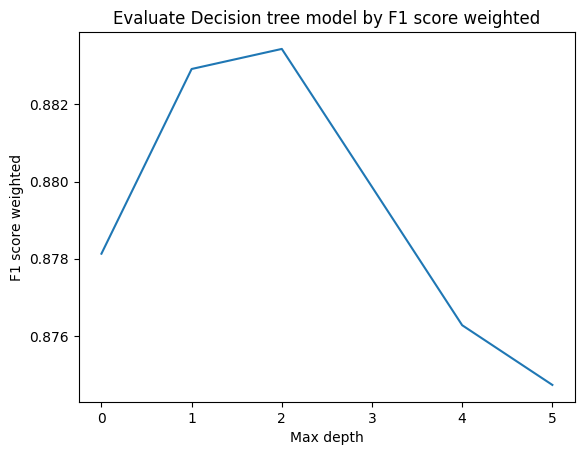

In [6]:
plot_grid('tree')

Fitting 5 folds for each of 4 candidates, totalling 20 fits


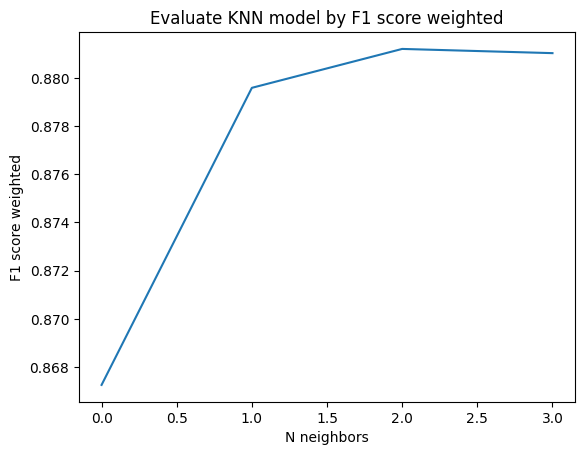

In [7]:
plot_grid('knn')

# Modeling

In [20]:
def evaluate_model(model, X, y, n_splits=5, shuffle=True):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=0)

    accuracy_scores = []
    balanced_acc_scores = []
    weighted_f1_scores = []
    auc_roc_scores = []
    confusion_matrices = []
    y_test_all = np.array([])
    y_pred_proba_all = np.array([])

    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model on the training fold
        model.fit(X_train, y_train)

        # Predict on the testing fold
        y_pred = model.predict(X_test)

        # Calculate evaluation metrics for the fold
        accuracy = accuracy_score(y_test, y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)

        # Calculate weighted F1 score
        f1_class0 = f1_score(y_test, y_pred, pos_label=0)
        f1_class1 = f1_score(y_test, y_pred, pos_label=1)

        n_samples = len(y_test)
        weight_class0 = np.count_nonzero(y_test == 0) / n_samples
        weight_class1 = np.count_nonzero(y_test == 1) / n_samples
        weighted_f1_score = (weight_class0 * f1_class0) + (weight_class1 * f1_class1)

        # Calculate AUC-ROC
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        auc_roc = roc_auc_score(y_test, y_pred_proba)

        y_test_all = np.concatenate([y_test_all, y_test])
        y_pred_proba_all = np.concatenate([y_pred_proba_all, y_pred_proba])

        # Calculate the confusion matrix for the fold
        cm = confusion_matrix(y_test, y_pred)

        # Save scores
        accuracy_scores.append(accuracy)
        balanced_acc_scores.append(balanced_acc)
        weighted_f1_scores.append(weighted_f1_score)
        auc_roc_scores.append(auc_roc)
        confusion_matrices.append(cm)

    # Calculate the average evaluation metrics across all folds
    average_accuracy = np.mean(accuracy_scores)
    average_balanced_acc = np.mean(balanced_acc_scores)
    average_weighted_f1 = np.mean(weighted_f1_scores)
    average_auc_roc = np.mean(auc_roc_scores)
    average_cm = np.mean(confusion_matrices, axis=0)
    fpr, tpr, thresholds = roc_curve(y_test_all, y_pred_proba_all)

    # Store the evaluation metrics in a dictionary
    return {
        'accuracy': average_accuracy,
        'balanced_acc': average_balanced_acc,
        'weighted_f1': average_weighted_f1,
        'auc_roc': {'score': average_auc_roc, 'fpt': fpr, 'tpr': tpr},
        'cm': average_cm,
    }

## Decision tree

In [21]:
# Create an instance of the Decision Tree Classifier
modelDTC = DecisionTreeClassifier(max_depth=20, random_state=0)

# Evaluate the Decision Tree model
evaluation_dtc = evaluate_model(modelDTC, X, y)

# Print the evaluation metrics
print('Accuracy:', evaluation_dtc['accuracy'])
print('Balanced Accuracy:', evaluation_dtc['balanced_acc'])
print('Weighted F1 Score:', evaluation_dtc['weighted_f1'])
print('AUC-ROC Score:', evaluation_dtc['auc_roc']['score'])
print('Confusion Matrix:\n', evaluation_dtc['cm'])

Accuracy: 0.8962991916696634
Balanced Accuracy: 0.5536101038000956
Weighted F1 Score: 0.8798360920498439
AUC-ROC Score: 0.6532084323175555
Confusion Matrix:
 [[56559.2  1925.2]
 [ 4707.4   767.2]]


## Naive Bayes

In [22]:
# Create an instance of the Gaussian Naive Bayes
modelNB = GaussianNB()

# Evaluate the Decision Tree model
evaluation_nb = evaluate_model(modelNB, X, y)

# Print the evaluation metrics
print('Accuracy:', evaluation_nb['accuracy'])
print('Balanced Accuracy:', evaluation_nb['balanced_acc'])
print('Weighted F1 Score:', evaluation_nb['weighted_f1'])
print('AUC-ROC Score:', evaluation_nb['auc_roc']['score'])
print('Confusion Matrix:\n', evaluation_nb['cm'])

Accuracy: 0.8468362544755234
Balanced Accuracy: 0.653815231421498
Weighted F1 Score: 0.8628763965621802
AUC-ROC Score: 0.7980438232982012
Confusion Matrix:
 [[51858.4  6626. ]
 [ 3170.2  2304.4]]


## KNN

In [23]:
# Create an instance of the K-nearest neighbor Classifier
modelKNN = KNeighborsClassifier(n_neighbors=2)

# Evaluate the Decision Tree model
evaluation_knn = evaluate_model(modelKNN, X, y)

# Print the evaluation metrics
print('Accuracy:', evaluation_knn['accuracy'])
print('Balanced Accuracy:', evaluation_knn['balanced_acc'])
print('Weighted F1 Score:', evaluation_knn['weighted_f1'])
print('AUC-ROC Score:', evaluation_knn['auc_roc']['score'])
print('Confusion Matrix:\n', evaluation_knn['cm'])

Accuracy: 0.9077534045247736
Balanced Accuracy: 0.5284657760081287
Weighted F1 Score: 0.8798511522883296
AUC-ROC Score: 0.6238664607355708
Confusion Matrix:
 [[57671.2   813.2]
 [ 5086.8   387.8]]


## Compare

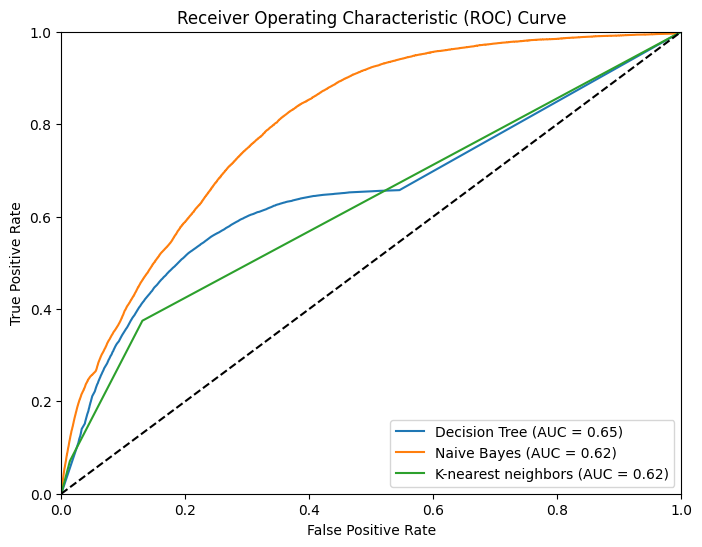

In [24]:
# Plot the ROC curves for each model
plt.figure(figsize=(8, 6))
plt.plot(evaluation_dtc['auc_roc']['fpt'], evaluation_dtc['auc_roc']['tpr'], label='Decision Tree (AUC = {:.2f})'.format(evaluation_dtc['auc_roc']['score']))
plt.plot(evaluation_nb['auc_roc']['fpt'], evaluation_nb['auc_roc']['tpr'], label='Naive Bayes (AUC = {:.2f})'.format(evaluation_knn['auc_roc']['score']))
plt.plot(evaluation_knn['auc_roc']['fpt'], evaluation_knn['auc_roc']['tpr'], label='K-nearest neighbors (AUC = {:.2f})'.format(evaluation_knn['auc_roc']['score']))
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line representing random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()
